In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [2]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [3]:
# DATA CLEANING

df.drop_duplicates(inplace = True)

df["director"].fillna("Unknown")
df["country"].fillna("Unknown")
df["cast"].fillna("Unknown")
df["rating"].fillna("Unknown")

0       PG-13
1       TV-MA
2       TV-MA
3       TV-MA
4       TV-MA
        ...  
8802        R
8803    TV-Y7
8804        R
8805       PG
8806    TV-14
Name: rating, Length: 8807, dtype: str

In [4]:
# MOVIES vs TV SHOWS
df["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

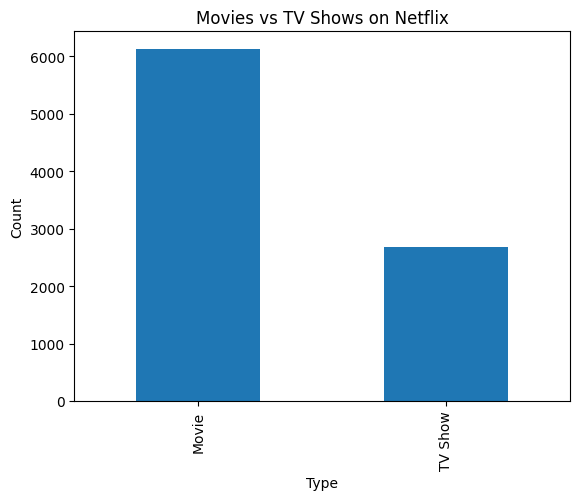

In [5]:
# MOVIES vs TV SHOWS BAR GRAPH
df["type"].value_counts().plot(kind = 'bar')

plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

In [6]:
# TOP 10 COUNTRIES PRODUCING CONTENT
top_countries = df["country"].value_counts().head(10)
print(top_countries)

country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64


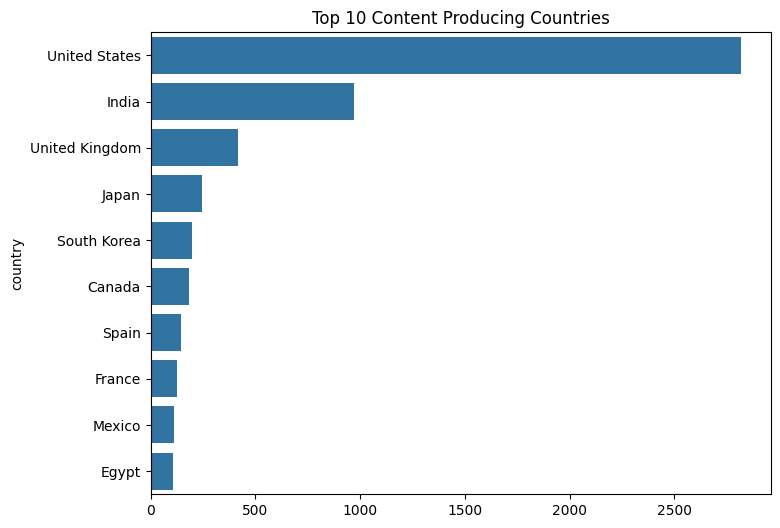

In [7]:
# TOP 10 COUNTRIES PRODUCING CONTENT VISUALISATION

plt.figure(figsize = (8,6))

sns.barplot(
    x = top_countries.values,
    y = top_countries.index
)

plt.title("Top 10 Content Producing Countries")
plt.show()

In [8]:
# DATE CONVERSION
df["date_added"] = pd.to_datetime(df["date_added"], errors = "coerce")
df["year_added"] = df["date_added"].dt.year

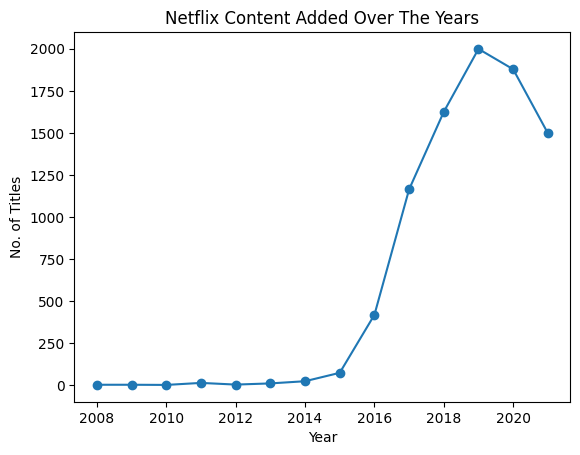

In [9]:
# CONTENT ADDED OVER THE YEARS

yrly_content = df["year_added"].value_counts().sort_index()
yrly_content.plot(kind = "line", marker = "o")

plt.title("Netflix Content Added Over The Years")
plt.xlabel("Year")
plt.ylabel("No. of Titles")

plt.show()

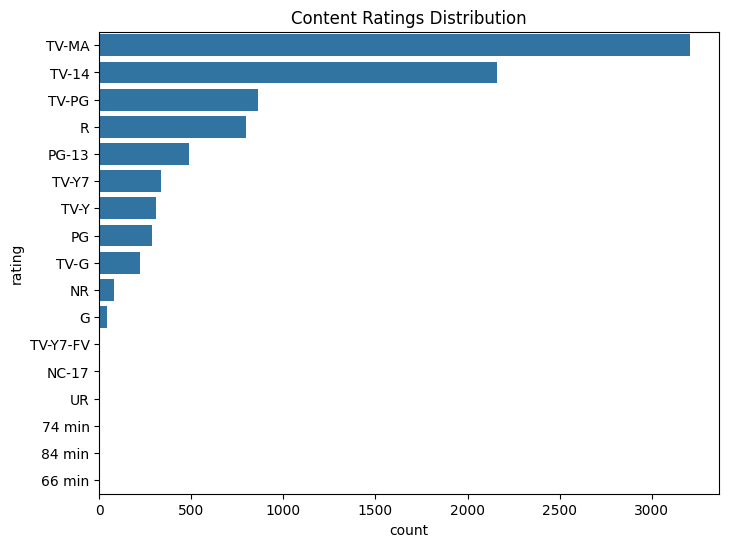

In [10]:
# RATINGS DISTRIBUTION

plt.figure(figsize = (8,6))

sns.countplot(
    y = df["rating"],
    order = df["rating"].value_counts().index
)

plt.title("Content Ratings Distribution")
plt.show()